In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime

프로그램 실행하시려면
1. 실행폴더 밑에 제가 올린 xlsx파일 있어야 합니다.
2. xlsx파일에서 'malgun.ttf' 파일 작업환경에 꺼내세요

In [ ]:
def mk_ttl_col(df):                        # 첫열(월별 기간) 인덱스화 및 대여 총계 컬럼 생성 함수
    df.set_index('월', inplace=True)
    df['Total'] = df.sum(axis=1)
    return df

def t(get_color = 'y'):                   # 작업환경이 어두운 Theme이라 텍스트 밝은색으로 만드는 함수
    plt.tick_params(color = get_color)
    plt.xticks(color = get_color)
    plt.yticks(color = get_color)

def mk_subplot(df, title_name, index):    # subplot 만드는 함수
    fp_ttl = fm.FontProperties(fname="HMKMG.ttf", size=16)    # 타이틀 폰트 및 크기 조정
    fp_lbl = fm.FontProperties(fname="HMKMG.ttf", size=12)    # 라벨 폰트 및 크기 조정

    plt.subplot(5, 2, index)              # 서브차트 10개
    df['Total'].plot(kind='bar')          # 바 차트 생성
    plt.title(title_name , c='w', fontproperties=fp_ttl)
    plt.xlabel('기간', c='w', fontproperties=fp_lbl)
    plt.ylabel('대여 도서', c='w', fontproperties=fp_lbl)
    t()

In [ ]:
df_TS = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_기술과학-세대별대출분석.xlsx"))
df_lit = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_문학-세대별대출분석.xlsx"))
df_SS = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_사회과학-세대별대출분석.xlsx"))
df_ling = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_언어-세대별대출분석.xlsx"))
df_hist = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_역사-세대별대출분석.xlsx"))
df_art = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_예술-세대별대출분석.xlsx"))
df_NS = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_자연과학-세대별대출분석.xlsx"))
df_rel = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_종교-세대별대출분석.xlsx"))
df_phil = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_철학-세대별대출분석.xlsx"))
df_ttl = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_총류-세대별대출분석.xlsx"))
# 서브플롯 반복문으로 생성하기 위해 딕셔너리화
dict_df = {'기술과학':df_TS,'문학':df_lit,'사회과학':df_SS,'언어':df_ling,'역사':df_hist,
           '예술':df_art,'자연과학':df_NS,'종교':df_rel,'철학':df_phil,'총류':df_ttl}

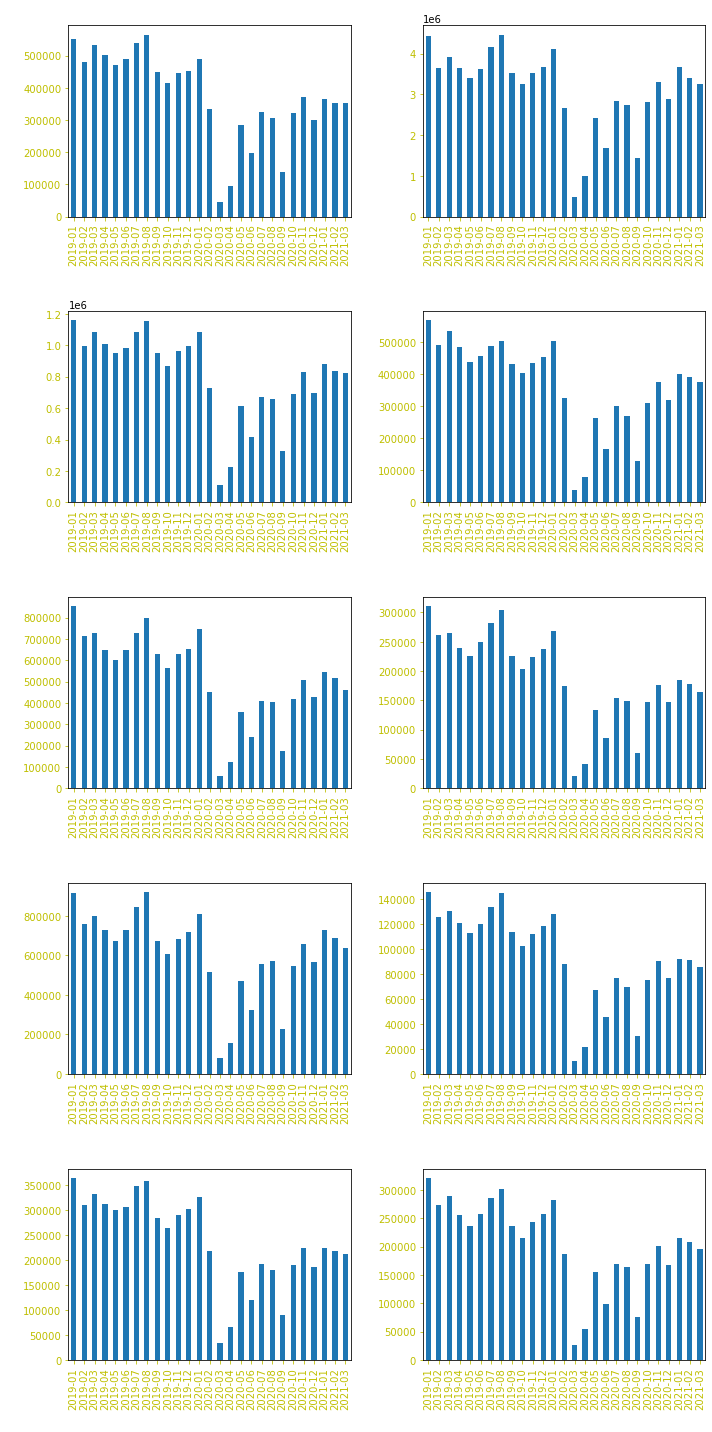

In [ ]:
plt.rcParams["figure.figsize"] = (10,20)   # 차트 크기
i = 1

for ttl in dict_df.keys():
    mk_subplot(dict_df[ttl], ttl, i)       # dataframe, dict_index, plot_index 넘겨주고
    i+=1

plt.tight_layout()
plt.savefig('Theme_data_result.png', facecolor='black')   # 내 마음속에 저~~장!!